In [1]:
import pandas as pd
import numpy as np

Basic exploration

In [2]:
#Loading datasets

customers = pd.read_csv(r"C:\Users\Smile\Documents\OJCommerce\QuickKart_TakeHome_Brief\quickkart_dataset\customers.csv")
sellers= pd.read_csv(r"C:\Users\Smile\Documents\OJCommerce\QuickKart_TakeHome_Brief\quickkart_dataset\sellers.csv")
products = pd.read_csv(r"C:\Users\Smile\Documents\OJCommerce\QuickKart_TakeHome_Brief\quickkart_dataset\products.csv")
orders = pd.read_csv(r"C:\Users\Smile\Documents\OJCommerce\QuickKart_TakeHome_Brief\quickkart_dataset\orders.csv")
order_items = pd.read_csv(r"C:\Users\Smile\Documents\OJCommerce\QuickKart_TakeHome_Brief\quickkart_dataset\order_items.csv")
shipments = pd.read_csv(r"C:\Users\Smile\Documents\OJCommerce\QuickKart_TakeHome_Brief\quickkart_dataset\shipments.csv")

#inspect shapes and datatypes
print("Customers shape:", customers.shape)
print("Sellers shape:", sellers.shape)
print("Products shape:", products.shape)
print("Orders shape:", orders.shape)
print("Order Items shape:", order_items.shape)
print("Shipments shape:", shipments.shape)
print("\nCustomers datatypes:\n", customers.dtypes)
print("\nSellers datatypes:\n", sellers.dtypes)
print("\nProducts datatypes:\n", products.dtypes)
print("\nOrders datatypes:\n", orders.dtypes)
print("\nOrder Items datatypes:\n", order_items.dtypes)
print("\nShipments datatypes:\n", shipments.dtypes)

Customers shape: (25000, 5)
Sellers shape: (400, 4)
Products shape: (3000, 4)
Orders shape: (100000, 7)
Order Items shape: (169929, 8)
Shipments shape: (91994, 9)

Customers datatypes:
 customer_id    object
signup_date    object
city           object
state          object
segment        object
dtype: object

Sellers datatypes:
 seller_id        object
seller_name      object
primary_city     object
rating          float64
dtype: object

Products datatypes:
 product_id      object
category        object
subcategory     object
base_price     float64
dtype: object

Orders datatypes:
 order_id                     object
customer_id                  object
created_at                   object
status                       object
payment_method               object
promised_delivery_date       object
is_fast_delivery_eligible      bool
dtype: object

Order Items datatypes:
 order_item_id        object
order_id             object
product_id           object
seller_id            object
quantity

In [3]:
shipments['delivery_status'].value_counts()

delivery_status
OnTime       63682
Late_1_2d    20388
InTransit     5043
Late_3_5d     2424
Lost           430
Late_5p         27
Name: count, dtype: int64

In [4]:
#convert date columns to datetime format
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
orders['created_at'] = pd.to_datetime(orders['created_at'])
orders['promised_delivery_date'] = pd.to_datetime(orders['promised_delivery_date'])
shipments['shipped_at'] = pd.to_datetime(shipments['shipped_at'])
shipments['delivered_at'] = pd.to_datetime(shipments['delivered_at'])  


In [5]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   order_id                   100000 non-null  object        
 1   customer_id                100000 non-null  object        
 2   created_at                 100000 non-null  datetime64[ns]
 3   status                     100000 non-null  object        
 4   payment_method             100000 non-null  object        
 5   promised_delivery_date     100000 non-null  datetime64[ns]
 6   is_fast_delivery_eligible  100000 non-null  bool          
dtypes: bool(1), datetime64[ns](2), object(4)
memory usage: 4.7+ MB


data quality check

In [6]:
print(shipments.isnull().sum())

shipment_id           0
order_id              0
carrier               0
shipped_at            0
delivered_at       5473
ship_from_city        0
ship_to_city          0
shipping_cost         0
delivery_status       0
dtype: int64


In [7]:

undelivered= shipments[shipments['delivered_at'].isnull()]
print(undelivered['delivery_status'].value_counts())


delivery_status
InTransit    5043
Lost          430
Name: count, dtype: int64


In [8]:
orders['status'].value_counts()

status
Delivered    82069
Cancelled     8006
Shipped       5043
Returned      4882
Name: count, dtype: int64

In [9]:
#filter for shipments that are physically completed
delivered_shipments= shipments[shipments['delivery_status'].isin(['OnTime', 'Late_1_2d', 'Late_3_5d','Late_5p'])]
status_check= delivered_shipments.merge(orders, on='order_id', how='inner')
print(pd.crosstab(status_check['delivery_status'], status_check['status'],margins=True))

status           Delivered  Returned    All
delivery_status                            
Late_1_2d            18001      2387  20388
Late_3_5d             2424         0   2424
Late_5p                 27         0     27
OnTime               61208      2474  63682
All                  81660      4861  86521


In [10]:
## There are 409 delivered orders (82069-81660) that is not accounted in the shipments table. possible assumption is that shipment data is not yet synchronised.
## there are 21 missing orders (4882 - 4861, because there are 4882 returns in the orders table but only 4861 returned according to the shipments table. This might represent returns that were intilaized but not shipped.

In [11]:
shipments['order_id'].duplicated().sum()

np.int64(0)

Deliverables

In [12]:
master_df = (order_items
.merge(products, on='product_id')
.merge(orders, on='order_id')
.merge(customers,on='customer_id')
.merge(shipments, on='order_id', how='left'))
master_df.head()



,order_item_id,order_id,product_id,seller_id,quantity,unit_price,discount_pct,platform_fee_pct,category,subcategory,...,state,segment,shipment_id,carrier,shipped_at,delivered_at,ship_from_city,ship_to_city,shipping_cost,delivery_status
0,OI0000001,ORD000001,P02970,S0327,2,748.0,0.00,0.15,Fashion,Men's Clothing,...,Delhi,Premium,SH000001,Ekart,2024-07-01 13:00:27,2024-07-02 18:41:52,Mumbai,Delhi,95.33,OnTime
1,OI0000002,ORD000002,P02457,S0282,1,53361.0,0.00,0.08,Electronics,Audio,...,Kerala,Budget,SH000002,Delhivery,2024-07-01 16:17:32,2024-07-03 04:35:14,Delhi,Kochi,109.57,Late_1_2d
2,OI0000003,ORD000003,P01998,S0310,3,1942.0,0.00,0.13,Fashion,Footwear,...,West Bengal,Value,SH000003,Delhivery,2024-07-01 14:39:14,2024-07-02 21:48:54,Jaipur,Kolkata,77.16,OnTime
3,OI0000004,ORD000004,P02964,S0288,1,21271.0,0.00,0.13,Home & Kitchen,Decor,...,Gujarat,Value,SH000004,Ekart,2024-07-01 15:26:20,2024-07-02 22:42:59,Kolkata,Ahmedabad,56.16,OnTime
4,OI0000005,ORD000004,P00822,S0350,1,6373.0,0.21,0.15,Fashion,Men's Clothing,...,Gujarat,Value,SH000004,Ekart,2024-07-01 15:26:20,2024-07-02 22:42:59,Kolkata,Ahmedabad,56.16,OnTime


In [13]:
master_df["GMV"]= master_df['quantity']*master_df['unit_price']
master_df['month']= master_df['created_at'].dt.to_period('M')
master_df.head()


,order_item_id,order_id,product_id,seller_id,quantity,unit_price,discount_pct,platform_fee_pct,category,subcategory,...,shipment_id,carrier,shipped_at,delivered_at,ship_from_city,ship_to_city,shipping_cost,delivery_status,GMV,month
0,OI0000001,ORD000001,P02970,S0327,2,748.0,0.00,0.15,Fashion,Men's Clothing,...,SH000001,Ekart,2024-07-01 13:00:27,2024-07-02 18:41:52,Mumbai,Delhi,95.33,OnTime,1496.0,2024-07
1,OI0000002,ORD000002,P02457,S0282,1,53361.0,0.00,0.08,Electronics,Audio,...,SH000002,Delhivery,2024-07-01 16:17:32,2024-07-03 04:35:14,Delhi,Kochi,109.57,Late_1_2d,53361.0,2024-07
2,OI0000003,ORD000003,P01998,S0310,3,1942.0,0.00,0.13,Fashion,Footwear,...,SH000003,Delhivery,2024-07-01 14:39:14,2024-07-02 21:48:54,Jaipur,Kolkata,77.16,OnTime,5826.0,2024-07
3,OI0000004,ORD000004,P02964,S0288,1,21271.0,0.00,0.13,Home & Kitchen,Decor,...,SH000004,Ekart,2024-07-01 15:26:20,2024-07-02 22:42:59,Kolkata,Ahmedabad,56.16,OnTime,21271.0,2024-07
4,OI0000005,ORD000004,P00822,S0350,1,6373.0,0.21,0.15,Fashion,Men's Clothing,...,SH000004,Ekart,2024-07-01 15:26:20,2024-07-02 22:42:59,Kolkata,Ahmedabad,56.16,OnTime,6373.0,2024-07


Deliverable 1 - Monthly GMV by city and category

In [14]:
#City
monthly_city_gmv = master_df.groupby(['month','city'])['GMV'].sum().reset_index()

#Category
monthly_category_gmv = master_df.groupby(['month','category'])['GMV'].sum().reset_index()

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

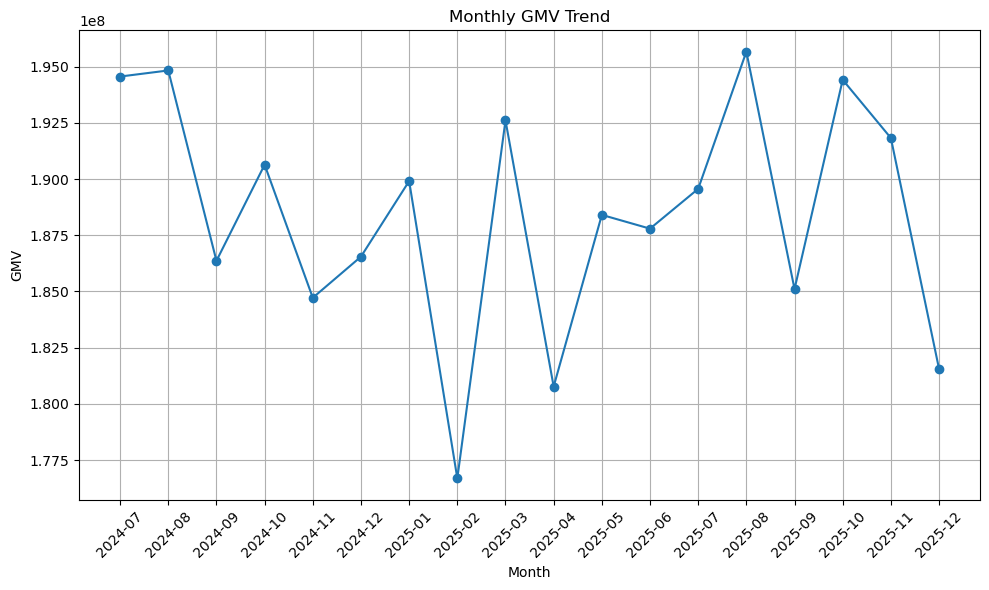

In [16]:
monthly_gmv = master_df.groupby('month')['GMV'].sum().reset_index()

plt.figure(figsize=(10,6))
plt.plot(monthly_gmv['month'].astype(str), monthly_gmv['GMV'], marker='o')
plt.title('Monthly GMV Trend')
plt.xlabel('Month')
plt.ylabel('GMV')
plt.xticks(rotation=45)
plt.grid() 
plt.tight_layout()
plt.show()

In [17]:
monthly_city_gmv

,month,city,GMV
0,2024-07,Ahmedabad,8474076.0
1,2024-07,Bangalore,27636566.0
2,2024-07,Chandigarh,7106669.0
3,2024-07,Chennai,19168930.0
4,2024-07,Delhi,29972017.0
...,...,...,...
211,2025-12,Kochi,3783324.0
212,2025-12,Kolkata,12415645.0
213,2025-12,Lucknow,6119100.0
214,2025-12,Mumbai,34234584.0


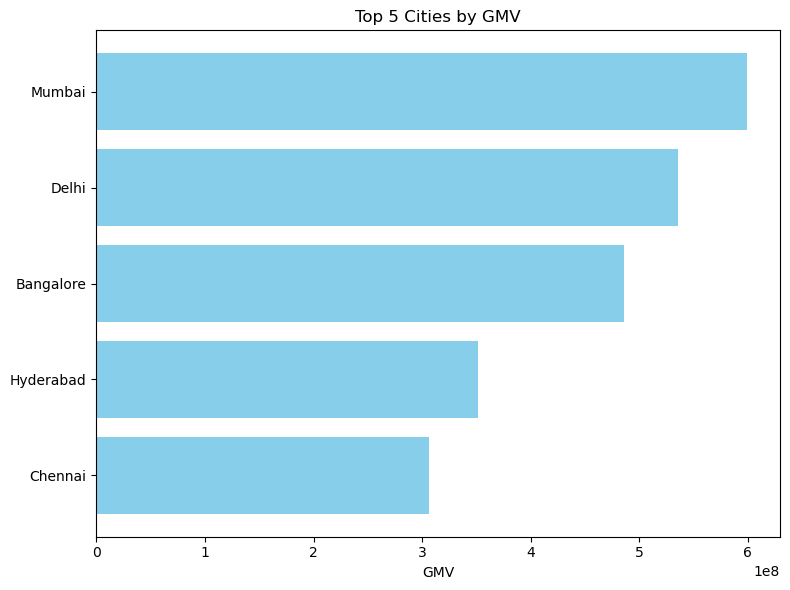

In [18]:
# Top 5 cities by GMV
top_cities = (
    monthly_city_gmv.groupby('city')['GMV'].sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

plt.figure(figsize=(8,6))
plt.barh(top_cities['city'], top_cities['GMV'], color='skyblue')
plt.title('Top 5 Cities by GMV')
plt.xlabel('GMV')
plt.gca().invert_yaxis()  # largest at top
plt.tight_layout()
plt.show()

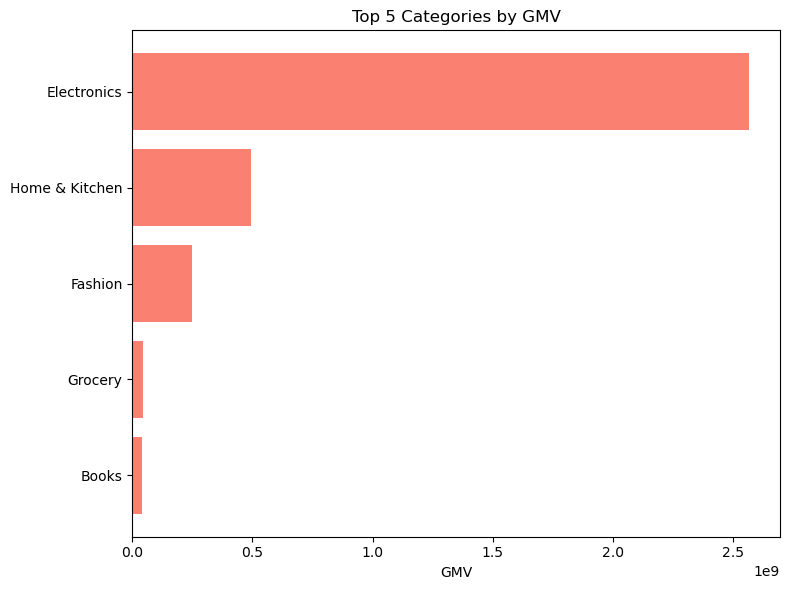

In [19]:
# Top 5 categories by GMV
top_categories = (
    monthly_category_gmv.groupby('category')['GMV'].sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

plt.figure(figsize=(8,6))
plt.barh(top_categories['category'], top_categories['GMV'], color='salmon')
plt.title('Top 5 Categories by GMV')
plt.xlabel('GMV')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Deliverable 2 -
Monthly orders and active customers

In [20]:
monthly_orders['month'].dtype

NameError: name 'monthly_orders' is not defined

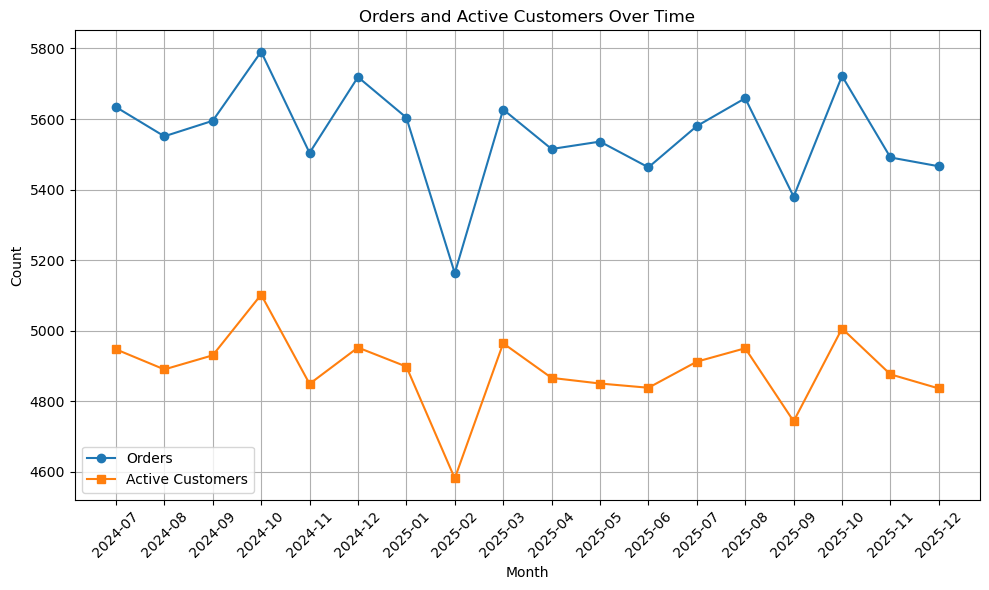

In [ ]:
# Monthly order count
orders['month']= orders['created_at'].dt.to_period('M')
monthly_orders= orders.groupby('month')['order_id'].nunique().reset_index(name='num_orders')

#Active customers

monthly_customers= orders.groupby('month')['customer_id'].nunique().reset_index(name='num_customers')

# Merge the two DataFrames on month
monthly_summary = monthly_orders.merge(monthly_customers, on='month')

plt.figure(figsize=(10,6))

# Plot orders
plt.plot(monthly_summary['month'].astype(str), monthly_summary['num_orders'],marker='o', label='Orders')

# Plot active customers
plt.plot(monthly_summary['month'].astype(str), monthly_summary['num_customers'],marker='s', label='Active Customers')

plt.title('Orders and Active Customers Over Time')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Deliverable 3 -
Monthly repeat purchase rate

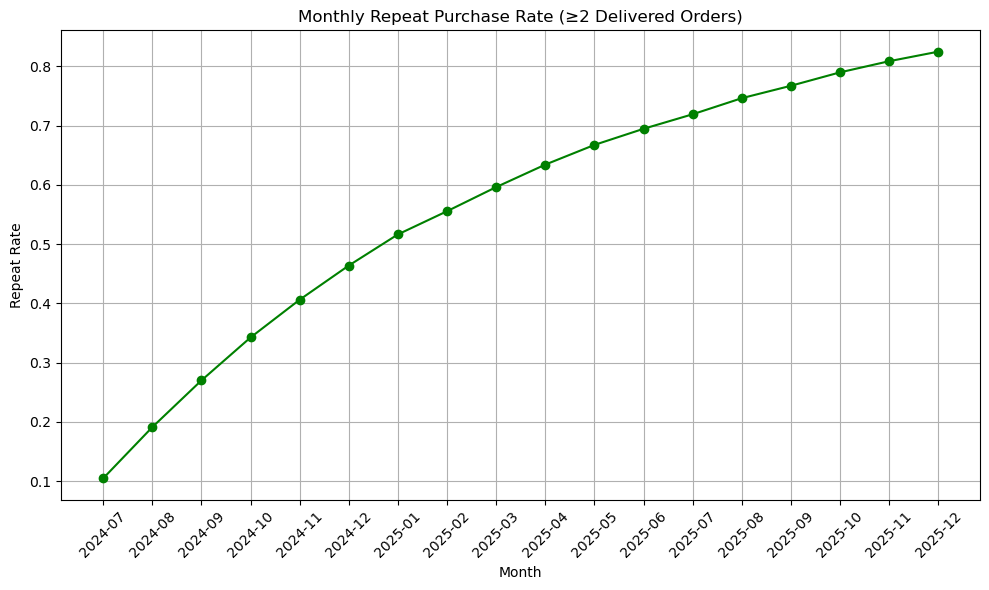

In [ ]:
delivered = orders[orders['status'] == 'Delivered'].copy()
delivered['created_at'] = pd.to_datetime(delivered['created_at'])
delivered['month'] = delivered['created_at'].dt.to_period('M')

monthly_repeat_r = []

for m in sorted(delivered['month'].unique()):
    up_to_month = delivered[delivered['month'] <= m]

    total_customers = up_to_month['customer_id'].nunique()
    repeat_customers = (
        up_to_month.groupby('customer_id')
                   .size()
                   .reset_index(name='delivered_orders')
                   .query('delivered_orders >= 2')['customer_id']
                   .nunique()
    )

    repeat_rate = repeat_customers / total_customers if total_customers else np.nan
    monthly_repeat_r.append((m, repeat_rate))

monthly_repeatd = pd.DataFrame(monthly_repeat_r, columns=['month', 'repeat_rate'])

plt.figure(figsize=(10, 6))
plt.plot(monthly_repeatd['month'].astype(str), monthly_repeatd['repeat_rate'],
         marker='o', color='green')
plt.title('Monthly Repeat Purchase Rate (≥2 Delivered Orders)')
plt.xlabel('Month')
plt.ylabel('Repeat Rate')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


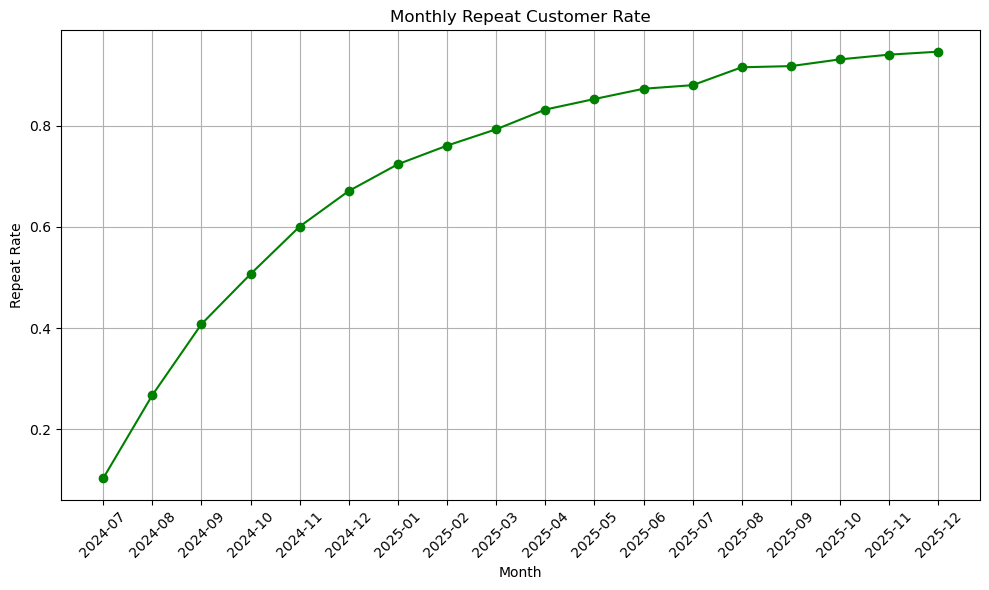

In [ ]:
delivered = (orders[orders['status']=='Delivered'].sort_values(['customer_id','created_at']))

delivered['order_num'] = (delivered.groupby('customer_id').cumcount()+ 1)

delivered['repeat_customer'] = (delivered['order_num'] >= 2)

delivered['month'] = (delivered['created_at'].dt.to_period('M'))

monthly_repeat = delivered.groupby('month')['repeat_customer'].mean().reset_index(name='repeat_rate')

plt.figure(figsize=(10,6))
plt.plot(monthly_repeat['month'].astype(str), monthly_repeat['repeat_rate'],marker='o', color='green')

plt.title('Monthly Repeat Customer Rate')
plt.xlabel('Month')
plt.ylabel('Repeat Rate')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()





In [ ]:
delivered

,order_id,customer_id,created_at,status,payment_method,promised_delivery_date,is_fast_delivery_eligible,month,order_num,repeat_customer
80279,ORD080280,C00001,2025-09-14,Delivered,UPI,2025-09-16,True,2025-09,1,False
5108,ORD005109,C00002,2024-07-29,Delivered,NetBanking,2024-07-31,True,2024-07,1,False
6628,ORD006629,C00002,2024-08-06,Delivered,UPI,2024-08-08,True,2024-08,2,True
52349,ORD052350,C00002,2025-04-12,Delivered,NetBanking,2025-04-14,True,2025-04,3,True
64087,ORD064088,C00002,2025-06-16,Delivered,COD,2025-06-19,False,2025-06,4,True
...,...,...,...,...,...,...,...,...,...,...
3757,ORD003758,C25000,2024-07-21,Delivered,UPI,2024-07-23,True,2024-07,2,True
25015,ORD025016,C25000,2024-11-14,Delivered,Wallet,2024-11-16,True,2024-11,3,True
26404,ORD026405,C25000,2024-11-22,Delivered,UPI,2024-11-24,True,2024-11,4,True
62806,ORD062807,C25000,2025-06-09,Delivered,COD,2025-06-11,True,2025-06,5,True


Deliverable 4 - 
Share of delayed orders by city and carrier

In [ ]:
shipments['is_delayed'] = (shipments['delivery_status']!= 'OnTime')

city_delay = (shipments.groupby('ship_to_city')['is_delayed'].mean().reset_index(name='delay_rate').sort_values('delay_rate', ascending=False).head(10))

carrier_delay = (shipments.groupby('carrier')['is_delayed'].mean().reset_index(name='delay_rate').sort_values('delay_rate', ascending=False).head(10))


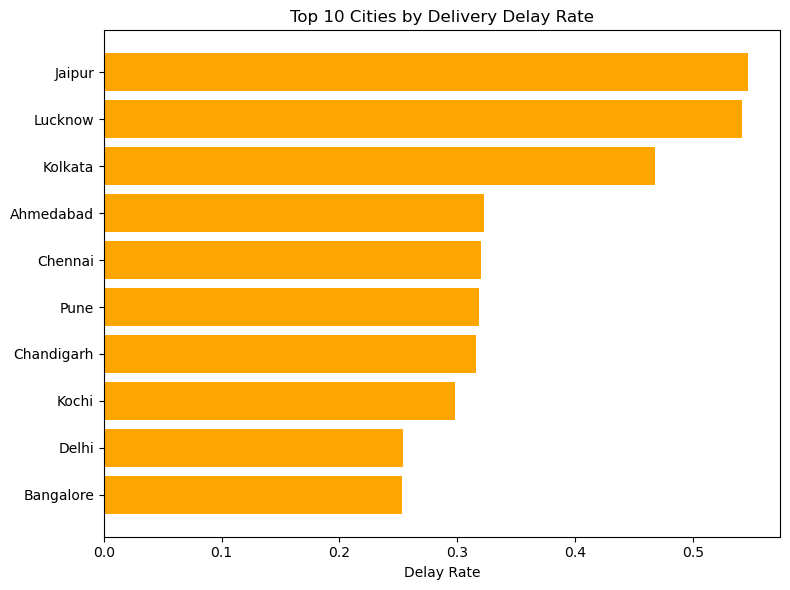

In [ ]:
#top 10 cities by delay 
plt.figure(figsize=(8,6))
plt.barh(city_delay['ship_to_city'], city_delay['delay_rate'], color='orange')
plt.title('Top 10 Cities by Delivery Delay Rate')
plt.xlabel('Delay Rate')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

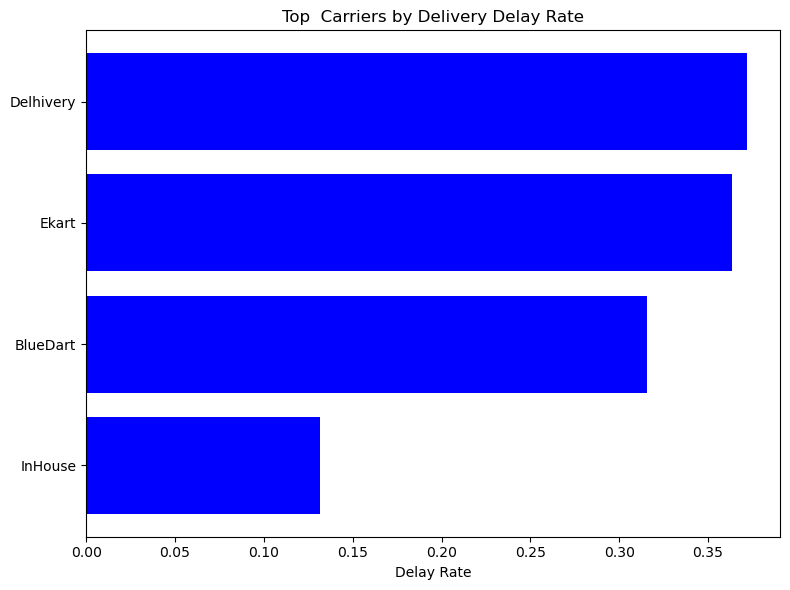

In [ ]:
# top carriers by delay 
plt.figure(figsize=(8,6))
plt.barh(carrier_delay['carrier'], carrier_delay['delay_rate'], color='blue')
plt.title('Top  Carriers by Delivery Delay Rate')
plt.xlabel('Delay Rate')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Practice

In [ ]:
customers['segment'].value_counts()

segment
Budget     10170
Value       9921
Premium     4909
Name: count, dtype: int64

In [ ]:
highest_customer_seg_by_gmv =master_df.groupby('segment')['GMV'].sum().reset_index(name = 'total_gmv').sort_values('total_gmv', ascending = False)
highest_customer_seg_by_gmv

,segment,total_gmv
2,Value,1.265198e+09
1,Premium,1.251907e+09
0,Budget,8.748885e+08


In [ ]:
# Which payment method is most popular
orders['payment_method'].value_counts()  

payment_method
UPI           35024
COD           24888
Card          20127
NetBanking    11997
Wallet         7964
Name: count, dtype: int64

In [ ]:
aoc = master_df.groupby('city')['GMV'].mean().reset_index(name='avg_gmv_by_city').sort_values('avg_gmv_by_city', ascending=False).head(10)
aoc


,city,avg_gmv_by_city
7,Kochi,20672.401611
0,Ahmedabad,20509.721806
5,Hyderabad,20393.348839
9,Lucknow,20116.209064
4,Delhi,20035.127690
1,Bangalore,20026.610187
3,Chennai,19939.413219
11,Pune,19856.984814
10,Mumbai,19762.503015
2,Chandigarh,19626.988013


In [ ]:
cat_gmv = master_df.groupby('category')['GMV'].sum().reset_index(name='total_gmv_by_category').sort_values('total_gmv_by_category', ascending=False)
cat_gmv

,category,total_gmv_by_category
1,Electronics,2.565817e+09
4,Home & Kitchen,4.932166e+08
2,Fashion,2.476219e+08
3,Grocery,4.583056e+07
0,Books,3.950810e+07


In [ ]:
shipments['carrier'].value_counts()

carrier
Delhivery    29539
BlueDart     21906
Ekart        21840
InHouse      18709
Name: count, dtype: int64

In [ ]:
# which cities have the highest delay rates

shipments['is_delayed'] = (shipments['delivery_status']!= 'OnTime')
delay_rates = shipments.groupby('ship_to_city')['is_delayed'].mean().reset_index(name='delay_rate').sort_values('delay_rate', ascending=False).head(10)
delay_rates

,ship_to_city,delay_rate
6,Jaipur,0.546621
9,Lucknow,0.542041
8,Kolkata,0.467890
0,Ahmedabad,0.322660
3,Chennai,0.319914
11,Pune,0.318515
2,Chandigarh,0.315531
7,Kochi,0.297680
4,Delhi,0.253993
1,Bangalore,0.253321


In [ ]:
cat_delay = (order_items.merge(shipments, on = 'order_id')
                        .merge(products[['product_id','category']], on = 'product_id', how = 'left')).groupby('category')['is_delayed'].mean().reset_index(name='delay_rate_by_category').sort_values('delay_rate_by_category', ascending=False)
cat_delay

# electronics orders are delayed more often than other categories, which could be due to factors like higher value, special handling requirements, or supply chain complexities.

,category,delay_rate_by_category
1,Electronics,0.399954
0,Books,0.277263
2,Fashion,0.271817
3,Grocery,0.270046
4,Home & Kitchen,0.269639


In [ ]:
segment_delay = (orders.merge(shipments, on = 'order_id')
                        .merge(customers[['customer_id','segment']], on = 'customer_id', how = 'left')).groupby('segment')['is_delayed'].mean().reset_index(name='delay_rate_by_segment').sort_values('delay_rate_by_segment', ascending=False)
segment_delay

#premium customers have fewer delays than other segments, which could be due to factors like priority handling, better logistics, or more reliable delivery partners.

,segment,delay_rate_by_segment
0,Budget,0.308420
2,Value,0.307717
1,Premium,0.307345


In [ ]:
shipments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91994 entries, 0 to 91993
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   shipment_id      91994 non-null  object        
 1   order_id         91994 non-null  object        
 2   carrier          91994 non-null  object        
 3   shipped_at       91994 non-null  datetime64[ns]
 4   delivered_at     86521 non-null  datetime64[ns]
 5   ship_from_city   91994 non-null  object        
 6   ship_to_city     91994 non-null  object        
 7   shipping_cost    91994 non-null  float64       
 8   delivery_status  91994 non-null  object        
dtypes: datetime64[ns](2), float64(1), object(6)
memory usage: 6.3+ MB


In [ ]:
cs = shipments.groupby('carrier')['shipping_cost'].mean().reset_index(name = 'avg_shipping_cost').sort_values('avg_shipping_cost', ascending=False)
cs

,carrier,avg_shipping_cost
0,BlueDart,108.630337
1,Delhivery,91.036667
2,Ekart,90.860020
3,InHouse,62.209757


In [ ]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169929 entries, 0 to 169928
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   order_item_id     169929 non-null  object 
 1   order_id          169929 non-null  object 
 2   product_id        169929 non-null  object 
 3   seller_id         169929 non-null  object 
 4   quantity          169929 non-null  int64  
 5   unit_price        169929 non-null  float64
 6   discount_pct      169929 non-null  float64
 7   platform_fee_pct  169929 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 10.4+ MB


In [ ]:
order_items_c = order_items.copy()
order_items_c['gmv']= order_items_c['quantity']*order_items_c['unit_price']
gmv_by_seller = (order_items_c.merge(sellers[['seller_id','seller_name']], on='seller_id')
                  .groupby('seller_name')['gmv'].sum().reset_index(name='total_gmv_by_seller')
                  .sort_values('total_gmv_by_seller', ascending=False)
                  .head(10))
gmv_by_seller

,seller_name,total_gmv_by_seller
355,Seller_59,11037527.0
386,Seller_87,10534363.0
367,Seller_7,10374280.0
215,Seller_293,10332820.0
191,Seller_271,10328531.0
70,Seller_162,10311024.0
48,Seller_142,10280207.0
328,Seller_395,10223101.0
383,Seller_84,10142055.0
93,Seller_183,10069772.0


In [ ]:
delayed_orders = master_df.copy()
delayed_orders['is_delayed'] = delayed_orders['delivery_status'] != 'OnTime'
delayed_orders_only = delayed_orders[delayed_orders['is_delayed']==True]
delayed_gmv_by_city = delayed_orders_only.groupby('city')['GMV'].sum().reset_index(name = 'delayed_gmv_by_city').sort_values('delayed_gmv_by_city', ascending=False).head(10)
delayed_gmv_by_city

,city,delayed_gmv_by_city
10,Mumbai,210571204.0
4,Delhi,196840616.0
1,Bangalore,179588572.0
3,Chennai,137173415.0
8,Kolkata,131757706.0
5,Hyderabad,130579936.0
11,Pune,117470124.0
6,Jaipur,86632768.0
9,Lucknow,82582612.0
0,Ahmedabad,74516411.0


In [ ]:
delayed_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169929 entries, 0 to 169928
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   order_item_id              169929 non-null  object        
 1   order_id                   169929 non-null  object        
 2   product_id                 169929 non-null  object        
 3   seller_id                  169929 non-null  object        
 4   quantity                   169929 non-null  int64         
 5   unit_price                 169929 non-null  float64       
 6   discount_pct               169929 non-null  float64       
 7   platform_fee_pct           169929 non-null  float64       
 8   category                   169929 non-null  object        
 9   subcategory                169929 non-null  object        
 10  base_price                 169929 non-null  float64       
 11  customer_id                169929 non-null  object  

In [ ]:
delay_gmv_by_carrier = delayed_orders.groupby('carrier')['GMV'].sum().reset_index(name = 'delayed_gmv_by_carrier').sort_values('delayed_gmv_by_carrier', ascending=False).head(10)
delay_gmv_by_carrier

,carrier,delayed_gmv_by_carrier
1,Delhivery,998733561.0
0,BlueDart,744256154.0
2,Ekart,739037082.0
3,InHouse,637978687.0


In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   order_id                   100000 non-null  object        
 1   customer_id                100000 non-null  object        
 2   created_at                 100000 non-null  datetime64[ns]
 3   status                     100000 non-null  object        
 4   payment_method             100000 non-null  object        
 5   promised_delivery_date     100000 non-null  datetime64[ns]
 6   is_fast_delivery_eligible  100000 non-null  bool          
dtypes: bool(1), datetime64[ns](2), object(4)
memory usage: 4.7+ MB


In [ ]:
orders[['created_at','promised_delivery_date','is_fast_delivery_eligible']].head()

,created_at,promised_delivery_date,is_fast_delivery_eligible
0,2024-07-01,2024-07-03,True
1,2024-07-01,2024-07-03,True
2,2024-07-01,2024-07-03,True
3,2024-07-01,2024-07-04,False
4,2024-07-01,2024-07-04,False


In [ ]:
master_df['status'].value_counts()

status
Delivered    139394
Cancelled     13576
Shipped        8615
Returned       8344
Name: count, dtype: int64

In [ ]:
delivered_df = master_df[master_df['delivered_at'].notnull()].copy()
delivered_df['delivery_duration_days'] = (delivered_df['delivered_at'] - delivered_df['created_at']).dt.total_seconds() / (24*3600)

avg_delivery_time = delivered_df.groupby('is_fast_delivery_eligible')['delivery_duration_days'].mean().reset_index(name='avg_delivery_time_days')
avg_delivery_time

,is_fast_delivery_eligible,avg_delivery_time_days
0,False,1.973757
1,True,1.965838


In [ ]:
delivered_df['delivery_duration_days']

0         1.779074
1         2.191134
2         1.908958
3         1.946516
4         1.946516
            ...   
169922    2.539468
169923    1.743796
169924    0.803785
169925    0.803785
169928    2.511134
Name: delivery_duration_days, Length: 147003, dtype: float64

Important⚠️

In [ ]:
delivery_status_share = pd.crosstab(
    master_df['is_fast_delivery_eligible'], 
    master_df['delivery_status'], 
    normalize='index'
) * 100
delivery_status_share

delivery_status,InTransit,Late_1_2d,Late_3_5d,Late_5p,Lost,OnTime
is_fast_delivery_eligible,,,,,,
False,5.429483,4.696264,0.595740,0.000000,0.491256,88.787257
True,5.553100,31.470840,3.662118,0.040275,0.458747,58.814920


In [ ]:
delayed_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169929 entries, 0 to 169928
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   order_item_id              169929 non-null  object        
 1   order_id                   169929 non-null  object        
 2   product_id                 169929 non-null  object        
 3   seller_id                  169929 non-null  object        
 4   quantity                   169929 non-null  int64         
 5   unit_price                 169929 non-null  float64       
 6   discount_pct               169929 non-null  float64       
 7   platform_fee_pct           169929 non-null  float64       
 8   category                   169929 non-null  object        
 9   subcategory                169929 non-null  object        
 10  base_price                 169929 non-null  float64       
 11  customer_id                169929 non-null  object  

In [ ]:
seller_delay_performance = delayed_orders.groupby('seller_id')['is_delayed'].mean().reset_index(name = 'delay_rate_by_seller')
seller_analysis_df = sellers.merge(seller_delay_performance, on = 'seller_id', how = 'inner')
correlation = seller_analysis_df['rating'].corr(seller_analysis_df['delay_rate_by_seller'])
print(correlation)

-0.5222242069378307


In [ ]:
seller_carrier_delay_rate = delayed_orders.groupby(['seller_id','carrier']).agg(
        delay_rate=('is_delayed', 'mean'),
        total_shipments=('is_delayed', 'count')).reset_index().sort_values('delay_rate', ascending=False).head(20)
seller_carrier_delay_rate

,seller_id,carrier,delay_rate,total_shipments
57,S0015,Delhivery,0.669291,127
22,S0006,Ekart,0.663158,95
17,S0005,Delhivery,0.646018,113
110,S0028,Ekart,0.643836,73
13,S0004,Delhivery,0.643411,129
113,S0029,Delhivery,0.638655,119
34,S0009,Ekart,0.636364,88
14,S0004,Ekart,0.635294,85
49,S0013,Delhivery,0.635036,137
114,S0029,Ekart,0.630435,92


High GMV + high delay cities

In [ ]:
high_GMV_high_delay_cities = (
    delayed_orders.groupby('city').agg(
        # Sums GMV ONLY for the rows where is_delayed is True
        delayed_gmv=('GMV', lambda x: x[delayed_orders.loc[x.index, 'is_delayed']].sum()),
        # Correctly calculates the proportion of late orders (True / Total)
        delay_rate=('is_delayed', 'mean'),
        # Optional: keeps track of total city revenue for context
        total_city_gmv=('GMV', 'sum')
    )
).reset_index().sort_values('delayed_gmv', ascending=False).head(10)

high_GMV_high_delay_cities

,city,delayed_gmv,delay_rate,total_city_gmv
10,Mumbai,210571204.0,0.301875,599732679.0
4,Delhi,196840616.0,0.313536,535358647.0
1,Bangalore,179588572.0,0.312937,486366255.0
3,Chennai,137173415.0,0.376724,306508660.0
8,Kolkata,131757706.0,0.513910,231285206.0
5,Hyderabad,130579936.0,0.313240,351173467.0
11,Pune,117470124.0,0.371559,265448173.0
6,Jaipur,86632768.0,0.576257,136651537.0
9,Lucknow,82582612.0,0.580684,135382087.0
0,Ahmedabad,74516411.0,0.373856,172589309.0


In [ ]:
# identify cities with high GMV and high delay rates to prioritize for improvement efforts
high_GMV_high_delay_cities = (delayed_orders.groupby('city').agg(
    total_gmv=('GMV', 'sum'),
    delay_rate=('is_delayed', 'mean')
)).reset_index().sort_values('delay_rate', ascending=False).head(10)
high_GMV_high_delay_cities


,city,total_gmv,delay_rate
9,Lucknow,135382087.0,0.580684
6,Jaipur,136651537.0,0.576257
8,Kolkata,231285206.0,0.513910
3,Chennai,306508660.0,0.376724
0,Ahmedabad,172589309.0,0.373856
11,Pune,265448173.0,0.371559
2,Chandigarh,104788489.0,0.369919
7,Kochi,66709840.0,0.354819
4,Delhi,535358647.0,0.313536
5,Hyderabad,351173467.0,0.313240


In [ ]:
seg_gmv = master_df.groupby(['month','segment'])['GMV'].sum().reset_index(name='monthly_gmv_by_segment')  
seg_gmv
pivot_seg_gmv = seg_gmv.pivot(index='month', columns='segment', values='monthly_gmv_by_segment').fillna(0)
pivot_seg_gmv

segment,Budget,Premium,Value
month,,,
2024-07,52533037.0,70991901.0,71036626.0
2024-08,48951681.0,72719940.0,73160656.0
2024-09,49968923.0,66338194.0,70057674.0
2024-10,50681358.0,69460875.0,70496995.0
2024-11,47497727.0,69222737.0,67999610.0
2024-12,46130555.0,71906627.0,68512569.0
2025-01,48353431.0,69937723.0,71620531.0
2025-02,47776695.0,66484908.0,62425195.0
2025-03,48276632.0,68272084.0,76063336.0


In [ ]:
# the average month-over-month growth rate %
mom_growth_pct = pivot_seg_gmv.pct_change()*100

print(mom_growth_pct.mean().sort_values(ascending=False))
# high-spending customers are contracting by about 0.22 % every month on average. 

segment
Value      0.077680
Premium   -0.223496
Budget    -0.641637
dtype: float64


In [ ]:
category_monthly_gmv = master_df.groupby(['month','category'])['GMV'].sum().reset_index( name = 'total_gmv_by_category')
category_monthly_gmv

,month,category,total_gmv_by_category
0,2024-07,Books,2249664.0
1,2024-07,Electronics,148398886.0
2,2024-07,Fashion,14267203.0
3,2024-07,Grocery,2600089.0
4,2024-07,Home & Kitchen,27045722.0
...,...,...,...
85,2025-12,Books,2135693.0
86,2025-12,Electronics,137644276.0
87,2025-12,Fashion,13797541.0
88,2025-12,Grocery,2452880.0


In [ ]:
pivot_cat_gmv = category_monthly_gmv.pivot(index ='month', columns = 'category', values = 'total_gmv_by_category').fillna(0)
pivot_cat_gmv

category,Books,Electronics,Fashion,Grocery,Home & Kitchen
month,,,,,
2024-07,2249664.0,148398886.0,14267203.0,2600089.0,27045722.0
2024-08,2160306.0,147554461.0,13881197.0,2594761.0,28641552.0
2024-09,2159560.0,139829845.0,13641265.0,2549486.0,28184635.0
2024-10,2379878.0,143946919.0,13742858.0,2575476.0,27994097.0
2024-11,2251597.0,140170556.0,13620483.0,2454325.0,26223113.0
2024-12,2313426.0,139730773.0,13971309.0,2682803.0,27851440.0
2025-01,2243350.0,143589731.0,13551591.0,2514574.0,28012439.0
2025-02,1977239.0,133407472.0,12473756.0,2414064.0,26414267.0
2025-03,2165546.0,145168368.0,13800902.0,2558575.0,28918661.0


In [ ]:
# average month over month growth rate %
mom_cat_growth_pct = pivot_cat_gmv.pct_change()*100
print(mom_cat_growth_pct.mean().sort_values(ascending = False))

category
Fashion          -0.077121
Books            -0.115159
Home & Kitchen   -0.187735
Grocery          -0.217764
Electronics      -0.340542
dtype: float64


In [ ]:
# what is happening to average order value
aov = master_df.groupby('month').agg(total_gmv = ('GMV','sum'),total_orders =('order_id','nunique')).reset_index()

aov['average_order_value'] = aov['total_gmv']/aov['total_orders']
aov

,month,total_gmv,total_orders,average_order_value
0,2024-07,194561564.0,5634,34533.468939
1,2024-08,194832277.0,5551,35098.590704
2,2024-09,186364791.0,5595,33309.167292
3,2024-10,190639228.0,5791,32919.915041
4,2024-11,184720074.0,5504,33561.059956
5,2024-12,186549751.0,5719,32619.295506
6,2025-01,189911685.0,5604,33888.594754
7,2025-02,176686798.0,5163,34221.731164
8,2025-03,192612052.0,5627,34229.971921
9,2025-04,180771429.0,5515,32778.137625


In [ ]:
orders['status'].value_counts()

status
Delivered    82069
Cancelled     8006
Shipped       5043
Returned      4882
Name: count, dtype: int64

In [ ]:
# Do delays impact cancellation

dci = delayed_orders.groupby('is_delayed')['status'].apply(lambda x: (x=='cancelled').mean()) 
dci

is_delayed
False    0.0
True     0.0
Name: status, dtype: float64

In [ ]:
# 1. Merge order items with order status and delivery status
items_extended = order_items.merge(orders[['order_id', 'status']], on='order_id', how='left')
items_extended = items_extended.merge(shipments[['order_id', 'delivery_status']], on='order_id', how='left')

# 2. Set up boolean flags
items_extended['is_cancelled'] = items_extended['status'] == 'Cancelled'
items_extended['is_delayed'] = items_extended['delivery_status'].isin(['Late_1_2d', 'Late_3_5d', 'Late_5p'])

# 3. Aggregate metrics per seller
seller_stats = items_extended.groupby('seller_id').agg(
    total_orders=('order_item_id', 'count'),
    cancellation_rate=('is_cancelled', 'mean'),
    # Delay rate evaluated only for orders that actually shipped
    shipping_delay_rate=('is_delayed', lambda x: x[items_extended.loc[x.index, 'status'] != 'Cancelled'].mean())
).reset_index()

# 4. Filter for active sellers to clear out low-volume noise
active_sellers = seller_stats[seller_stats['total_orders'] >= 50]

# 5. Compute the correlation coefficient
correlation = active_sellers['shipping_delay_rate'].corr(active_sellers['cancellation_rate'])
print(f"Correlation between Seller Delay Rate and Cancellation Rate: {correlation:.4f}")

Correlation between Seller Delay Rate and Cancellation Rate: -0.0242


In [28]:
shipments['is_delayed'] = shipments['delivery_status'] != 'OnTime'


lane_df = order_items.merge(
    shipments[['order_id', 'carrier', 'ship_to_city', 'is_delayed']], 
    on='order_id', 
    how='inner'
)

lane_df = lane_df.merge(sellers[['seller_id', 'seller_name']], on='seller_id', how='inner')


lane_performance = (
    lane_df.groupby(['seller_name', 'carrier', 'ship_to_city'])
    .agg(
        delay_rate=('is_delayed', 'mean'),
        total_orders=('is_delayed', 'count')
    )
    .reset_index()
)


min_lane_volume = 15 
significant_lanes = lane_performance[lane_performance['total_orders'] >= min_lane_volume]


worst_performing_lanes = significant_lanes.sort_values(by='delay_rate', ascending=False).head(10)

worst_performing_lanes

,seller_name,carrier,ship_to_city,delay_rate,total_orders
13740,Seller_50,Ekart,Kolkata,0.833333,18
9422,Seller_312,Ekart,Kolkata,0.823529,17
15404,Seller_9,BlueDart,Chennai,0.812500,16
15421,Seller_9,Delhivery,Kolkata,0.800000,15
4748,Seller_206,Ekart,Kolkata,0.800000,15
15429,Seller_9,Ekart,Delhi,0.789474,19
926,Seller_12,Delhivery,Chennai,0.777778,18
2968,Seller_166,Ekart,Kolkata,0.777778,18
7066,Seller_26,Delhivery,Delhi,0.764706,17
1364,Seller_13,Delhivery,Delhi,0.750000,16
